# 02 — First model (weekly retail Δ)

Research backtest, not production. Ridge only. No extra downloads. No LA RBOB.

**Target:** `retail_price(Monday T+7) − retail_price(Monday T)` in $/gal.

**Prediction clock:** Tuesday 12:00 p.m. ET after Monday T.

**Question:** Does lagged daily WTI / NY Harbor / Gulf Coast improve one-week-ahead U.S. regular retail change versus a retail-momentum baseline?

Full write-up: `reports/first_model_results.md`.


In [1]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use("Agg")
import pandas as pd

ROOT = Path.cwd()
if (ROOT / "src" / "modeling").exists():
    pass
elif (ROOT / "gas_wait" / "src" / "modeling").exists():
    ROOT = ROOT / "gas_wait"
elif (ROOT / "notebooks").exists() and (ROOT.parent / "src" / "modeling").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from modeling.build_features import ALL_MODEL_FEATURES, _assert_no_leakage, build_weekly_model_dataset
from modeling.evaluate import (
    DECISION_THRESHOLDS,
    MODEL_LABELS,
    decision_metrics,
    regression_metrics,
)
from modeling.train_baseline import chronological_split, fit_predict_holdout, walk_forward_all

result = build_weekly_model_dataset()
df = result.frame
dropped = result.dropped
print(f"kept={len(df)} dropped={len(dropped)}")
print(df["prediction_date"].min().date(), "→", df["prediction_date"].max().date())
df.head()


kept=1747 dropped=132
1993-01-19 → 2026-08-11
  prediction_date         prediction_ts_utc  target target_timestamp retail_monday retail_feature_timestamp spot_feature_timestamp inventory_feature_timestamp  inventory_release_ts_utc  retail_d7  retail_d14  wti_d1  wti_d3  wti_d5  wti_vol_20  nyh_d1  nyh_d5  nyh_vol_20  gc_d1  gc_d5  crack_nyh_d5  inv_wow  inv_seasonal_z   sin_doy   cos_doy  is_summer  retail_last  wti_chg_7cal  month  is_holiday_travel_week
0      1993-01-19 1993-01-19 17:00:00+00:00  -0.006       1993-01-25    1993-01-18               1993-01-18             1993-01-18                  1993-01-08 1993-01-13 17:00:00+00:00     -0.005      -0.004    0.05    0.43    0.16    0.215385   0.000   0.013    0.007850 -0.002  0.011         0.386   4745.0        0.599895  0.321058  0.947060          0        1.061          0.16      1                       0
1      1993-01-26 1993-01-26 17:00:00+00:00   0.000       1993-02-01    1993-01-25               1993-01-25             1993-0

## Leakage checks (must pass before training)


In [2]:
_assert_no_leakage(df)

checks = pd.DataFrame(
    {
        "check": [
            "spot timestamp <= Monday T",
            "spot timestamp < prediction Tuesday",
            "inventory Friday lag >= 10 days",
            "inventory release <= prediction_ts",
            "target is exactly Monday T+7",
            "no LA RBOB columns",
            "features have no NA",
        ],
        "pass": [
            df["spot_feature_timestamp"].le(df["retail_monday"]).all(),
            df["spot_feature_timestamp"].lt(df["prediction_date"]).all(),
            ((df["prediction_date"] - df["inventory_feature_timestamp"]).dt.days >= 10).all(),
            df["inventory_release_ts_utc"].le(df["prediction_ts_utc"]).all(),
            (df["target_timestamp"] - df["retail_monday"]).dt.days.eq(7).all(),
            not any("rbob" in c.lower() or "la_" in c.lower() for c in df.columns),
            not df[ALL_MODEL_FEATURES].isna().any().any(),
        ],
    }
)
checks


                                 check  pass
0           spot timestamp <= Monday T  True
1  spot timestamp < prediction Tuesday  True
2      inventory Friday lag >= 10 days  True
3   inventory release <= prediction_ts  True
4         target is exactly Monday T+7  True
5                   no LA RBOB columns  True
6                  features have no NA  True


## Dropped rows


In [3]:
dropped["reason_group"] = dropped["reason"].str.split(":").str[0]
dropped["reason_group"].value_counts().rename("count").to_frame()


                                       count
reason_group                                
missing_required_features                124
missing_retail_at_t                        6
missing_or_nonweekly_retail_at_tplus7      2


## Train / test

Chronological 70/30. No shuffling. Ridge alpha is frozen at 1.0.


In [4]:
split = chronological_split(df)
holdout = fit_predict_holdout(split)
walk = walk_forward_all(df)
print("train", split.train["prediction_date"].min().date(), "→", split.train["prediction_date"].max().date(), len(split.train))
print("test ", split.test["prediction_date"].min().date(), "→", split.test["prediction_date"].max().date(), len(split.test))


train 1993-01-19 → 2016-07-12 1222
test  2016-07-19 → 2026-08-11 525


## Holdout regression


In [5]:
rows = []
for name, label in MODEL_LABELS.items():
    m = regression_metrics(split.test["target"], holdout[name].predictions)
    m["model"] = label
    rows.append(m)
pd.DataFrame(rows).set_index("model")[["n", "mae", "rmse", "r2", "corr", "directional_accuracy"]]


                                                                n       mae      rmse        r2      corr  directional_accuracy
model                                                                                                                          
MODEL 1: Momentum baseline (retail_d7)                      525.0  0.039512  0.062137  0.089074  0.544373              0.681298
MODEL 2: Ridge, retail momentum only                        525.0  0.034981  0.054898  0.288965  0.538496              0.694656
MODEL 3: Ridge, retail + daily markets                      525.0  0.029319  0.046429  0.491430  0.716400              0.774809
MODEL 4: Ridge, retail + markets + inventory + seasonality  525.0  0.028646  0.045519  0.511154  0.725148              0.772901


## Walk-forward regression


In [6]:
actual = df.set_index("prediction_date")["target"]
rows = []
for name, label in MODEL_LABELS.items():
    aligned = pd.concat([actual, walk[name].rename("pred")], axis=1).dropna()
    m = regression_metrics(aligned["target"], aligned["pred"])
    m["model"] = label
    rows.append(m)
pd.DataFrame(rows).set_index("model")[["n", "mae", "rmse", "r2", "corr", "directional_accuracy"]]


                                                                 n       mae      rmse        r2      corr  directional_accuracy
model                                                                                                                           
MODEL 1: Momentum baseline (retail_d7)                      1021.0  0.039996  0.058060  0.177229  0.588448              0.699803
MODEL 2: Ridge, retail momentum only                        1021.0  0.036218  0.052377  0.330424  0.575842              0.703740
MODEL 3: Ridge, retail + daily markets                      1021.0  0.029449  0.044526  0.516097  0.726974              0.792323
MODEL 4: Ridge, retail + markets + inventory + seasonality  1021.0  0.029107  0.043839  0.530929  0.734904              0.791339


## Decision metrics (δ = $0.03 / $0.04 / $0.05)


In [7]:
dec_rows = []
for delta in DECISION_THRESHOLDS:
    for name, label in MODEL_LABELS.items():
        d = decision_metrics(split.test["target"], holdout[name].predictions, delta)
        d["model"] = label
        dec_rows.append(d)
pd.DataFrame(dec_rows).set_index(["delta", "model"])[
    [
        "n_wait",
        "n_fill",
        "n_none",
        "pct_no_signal",
        "pct_correct_among_signals",
        "mean_actual_after_wait",
        "mean_actual_after_fill",
        "mean_savings_per_fill_usd",
    ]
]


                                                                  n_wait  n_fill  n_none  pct_no_signal  pct_correct_among_signals  mean_actual_after_wait  mean_actual_after_fill  mean_savings_per_fill_usd
delta model                                                                                                                                                                                                  
0.03  MODEL 1: Momentum baseline (retail_d7)                       129.0   138.0   258.0       0.491429                   0.786517               -0.043690                0.046920                   0.161029
      MODEL 2: Ridge, retail momentum only                          64.0    72.0   389.0       0.740952                   0.823529               -0.060828                0.060167                   0.111229
      MODEL 3: Ridge, retail + daily markets                       102.0   119.0   304.0       0.579048                   0.895928               -0.056167                0.0654

## Charts


reports/figures/holdout_actual_vs_predicted.png
reports/figures/holdout_residuals.png
reports/figures/holdout_prediction_distribution.png
reports/figures/holdout_cumulative_savings.png
reports/figures/holdout_mae_by_year.png


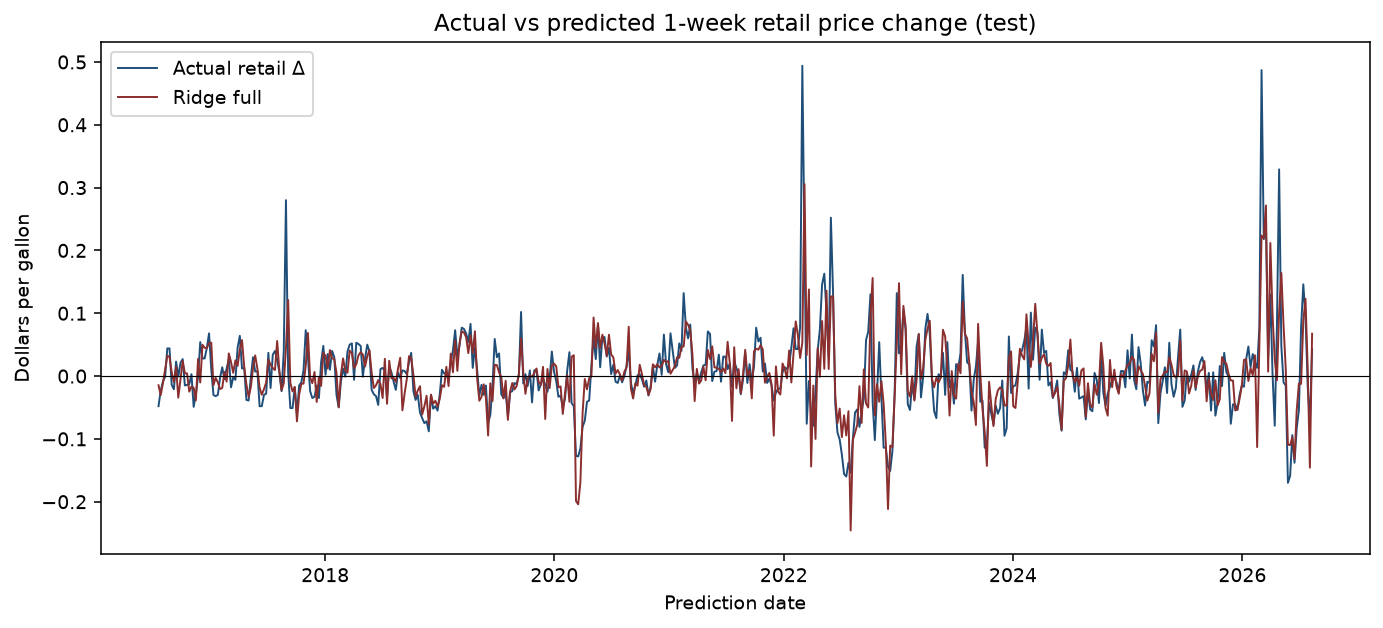

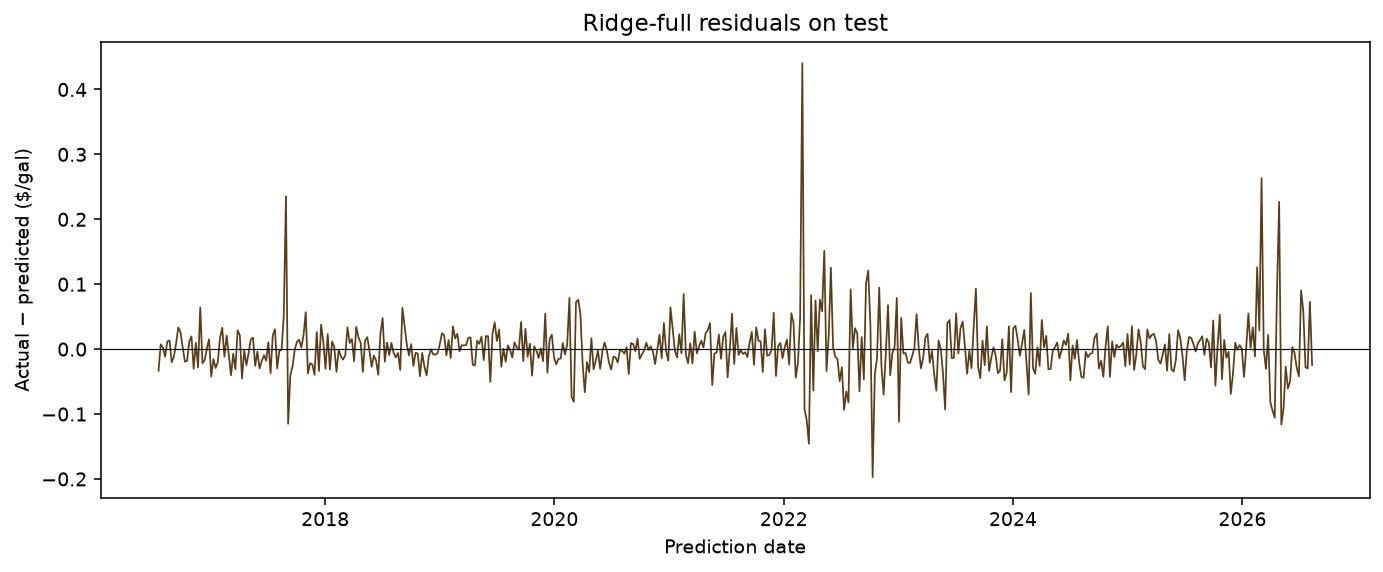

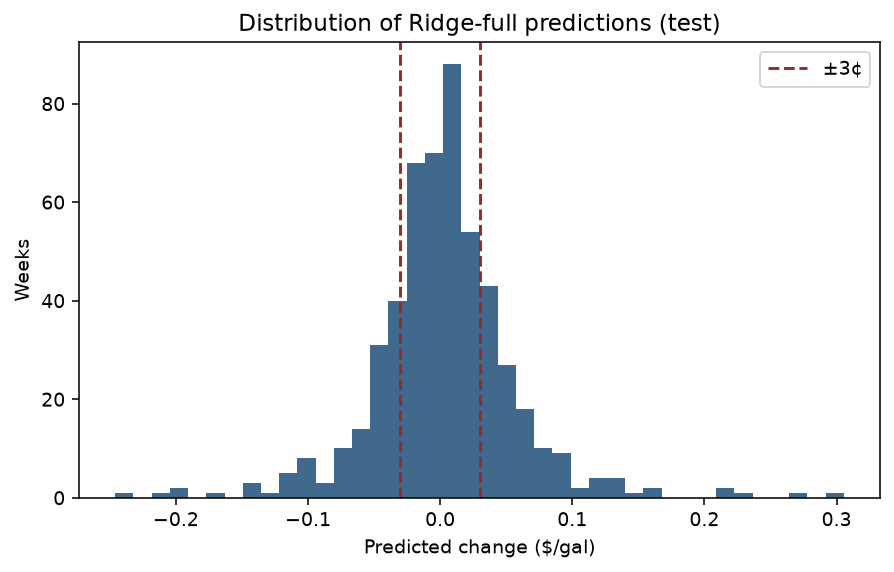

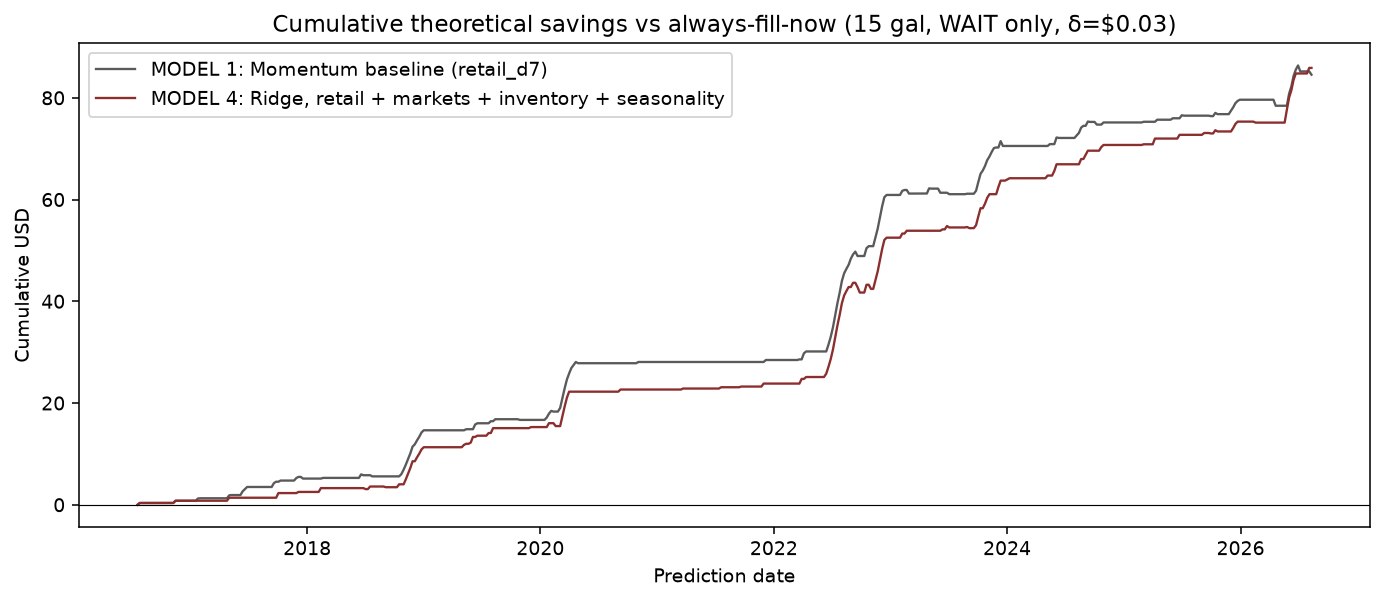

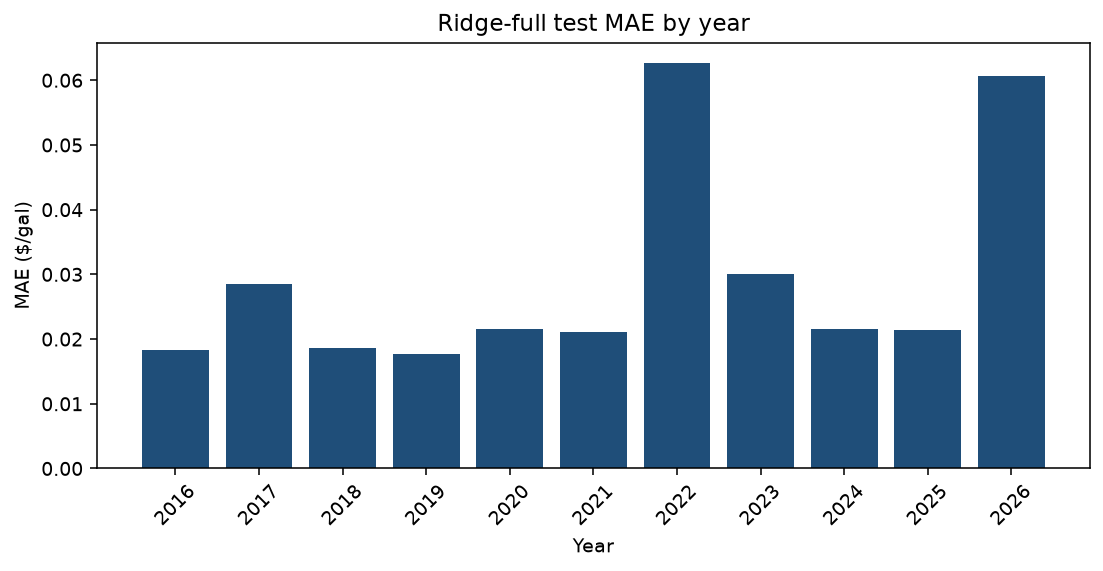

In [8]:
from matplotlib import image as mpimg
import matplotlib.pyplot as plt

fig_dir = ROOT / "reports" / "figures"
for name in [
    "holdout_actual_vs_predicted.png",
    "holdout_residuals.png",
    "holdout_prediction_distribution.png",
    "holdout_cumulative_savings.png",
    "holdout_mae_by_year.png",
]:
    path = fig_dir / name
    print(path.relative_to(ROOT))
    img = mpimg.imread(path)
    plt.figure(figsize=(10, 4.4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(name)
    plt.close()


## Honest takeaways

1. **Ridge beats momentum** on MAE and direction (MODEL 4 holdout MAE 2.86¢ vs 3.95¢; direction 77% vs 68%).
2. **Daily wholesale/crude features are the lift.** MODEL 3 vs MODEL 2 is the large jump.
3. **Inventory + seasonality add almost nothing** once markets are in (~0.07¢ MAE).
4. **Economic benefit is small in dollars:** ~$0.16 per 15-gallon fill vs always-fill-now on WAIT calls only. FILL quality is better than momentum, but that does not show up in the always-fill P&L by construction.
5. **~57% of weeks are silent** at a 3¢ dead zone.
6. This is **not** a 3-day local product. It is evidence that hub spots lead *national weekly* pumps, which is a reason to buy licensed daily retail — not a reason to ship an app on EIA Mondays.
